In [1]:
from pathlib import Path

import numpy as np
from dataeval.data import ClassFilter, Limit, Shuffle, View
from datamaite import load_ic
from maite_datasets.image_classification import MilitaryVehicles

data_root = Path("./data")
MilitaryVehicles(root=data_root, image_set="base", download=True)
MilitaryVehicles(root=data_root, image_set="train", as_datamaite=True)

vehicles_raw = load_ic(data_root / "militaryvehicles_datamaite_train" / "train", dataset_format="huggingface_vision")
index2label = vehicles_raw.metadata.get("index2label", {})

# The category this collection cycle never captured.
AIR_DEFENSE = {"30N6E", "Iskander", "Pantsir-S1", "Rs-24"}
collected_classes = [i for i, name in index2label.items() if name not in AIR_DEFENSE]

# `ClassFilter` enforces the gap by filtering on sample labels.
# `Shuffle` and `Limit` sample the result for faster execution.
collected = View(vehicles_raw, [ClassFilter(collected_classes), Shuffle(seed=0), Limit(1500)])

print(f"Full collection:  {len(vehicles_raw)} frames, {len(index2label)} types")
print(f"After the gap:    {len(collected)} frames, {len(collected_classes)} types")
print(f"Never collected:  {sorted(AIR_DEFENSE)}")

/builds/jatic/aria/dataeval-flow/.nox/docs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Full collection:  7823 frames, 24 types
After the gap:    1500 frames, 20 types
Never collected:  ['30N6E', 'Iskander', 'Pantsir-S1', 'Rs-24']


In [2]:
labels = np.array([int(np.argmax(collected[i][1])) for i in range(len(collected))])
class_counts = {index2label[c]: int((labels == c).sum()) for c in sorted(set(labels.tolist()))}
ordered = sorted(class_counts.items(), key=lambda kv: -kv[1])

largest, smallest = ordered[0], ordered[-1]
ratio = largest[1] / smallest[1]
print(f"Largest class:  {largest[0]} ({largest[1]})")
print(f"Smallest class: {smallest[0]} ({smallest[1]})")
print(f"Imbalance ratio: {ratio:.2f}:1")

Largest class:  BTR-80 (94)
Smallest class: T-90 (53)
Imbalance ratio: 1.77:1


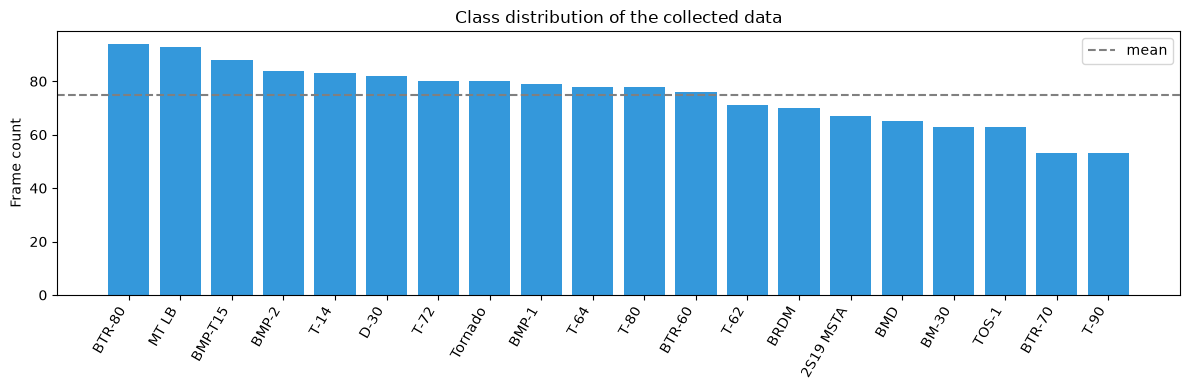

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
names = [n for n, _ in ordered]
values = [v for _, v in ordered]
ax.bar(names, values, color="#3498db")
ax.axhline(y=float(np.mean(values)), color="gray", linestyle="--", label="mean")
ax.set_ylabel("Frame count")
ax.set_title("Class distribution of the collected data")
ax.tick_params(axis="x", rotation=60)
for tick in ax.get_xticklabels():
    tick.set_horizontalalignment("right")
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
from dataeval_flow import PipelineConfig, run_task
from dataeval_flow.config import DatasetProtocolConfig, MetadataPolicyConfig, SourceConfig, TaskConfig
from dataeval_flow.workflows.data_coverage import DataCoverageConfig

vehicle_factors = MetadataPolicyConfig(
    name="vehicle_factors",
    # Nothing in this dataset's own per-sample metadata is a collection condition:
    # `id` is unique per frame (so it looks perfectly class-predictive) and height and
    # width describe the crop, not the scene. Ask for measured image statistics instead.
    intrinsic_factors=["visual", "pixel"],
    exclude=["id", "height", "width"],
    # Explicitly declared bins keep factor cuts consistent across runs.
    continuous_factor_bins={
        "brightness": 5,
        "contrast": 5,
        "darkness": 5,
        "entropy": 5,
        "kurtosis": 5,
        "mean": 5,
        "sharpness": 5,
        "skew": 5,
        "std": 5,
        "var": 5,
        "zeros": 5,
    },
)

metadata_only_workflow = DataCoverageConfig(
    name="coverage-metadata-only",
    metadata="vehicle_factors",
    gaps={"min_representation": 5},  # Flag class-factor-value combos with < 5 samples
    diversity="simpson",
    health_thresholds={
        "class-imbalance": {"ratio": 3.0},  # Catch moderate class imbalance
        "coverage-gaps": {"count": 2},  # Warn if >= 2 gaps found
    },
)

task_metadata = TaskConfig(
    name="vehicles-coverage-metadata",
    workflow="coverage-metadata-only",
    sources="vehicles_src",
    # No extractor for metadata-only pass
)

config_metadata = PipelineConfig(
    metadata=[vehicle_factors],
    datasets=[
        DatasetProtocolConfig(name="vehicles_collected", format="maite", dataset=collected),
    ],
    sources=[
        SourceConfig(name="vehicles_src", dataset="vehicles_collected"),
    ],
    workflows=[metadata_only_workflow],
    tasks=[task_metadata],
)

In [5]:
result_metadata = run_task(task_metadata, config_metadata, cache_dir=Path("./cache"))

/builds/jatic/aria/dataeval-flow/src/dataeval_flow/workflows/_common.py:60: UserWarning: Declared cuts left bins unused: kurtosis (4 of 5 bins hold rows). The encoding still applies and the codes are unchanged; this is the data no longer matching the policy, not an error. Call reencode() to refit — which moves codes — or leave it and read the empty groups as the finding they are.
  factor_info = metadata.factor_info


In [6]:
print(result_metadata.report())


  DATA COVERAGE
  Workflow:  coverage-metadata-only (data-coverage)
  Timestamp: 2026-10-03T21:51:26.647044+00:00
  Duration:  0.61s
  Source:    vehicles_src (vehicles_collected)

  Steps: 14 (12 ran, 2 skipped)

  SUMMARY
  Embedding Coverage ...................................... not assessed  [..]
  Dimensional Completeness ................................ not assessed  [..]
  Label Distribution ........... 24 classes, 1500 items, imbalance 1.8:1  [!!]
  Metadata Coverage Gaps .................. No significant gaps detected  [ok]
  Class Balance Worklist ................. 6 classes short · deficit 266  [..]

  Health: 1 warning(s) [!!] — review flagged findings

  EMBEDDING COVERAGE                                                not assessed
  Not assessed: `coverage` was skipped: requires an extractor.

  From Coverage — skipped
    Skipped: requires an extractor

  DIMENSIONAL COMPLETENESS                                          not assessed
  Not assessed: `completeness` was s

In [7]:
label_health = result_metadata.steps["labels"].output.data()
print(f"Number of classes: {label_health['class_count']}")
print(f"Empty images: {label_health['empty_image_count']}")
print("\nClass distribution (five largest, five smallest):")
by_size = sorted(label_health["label_counts_per_class"].items(), key=lambda x: x[1], reverse=True)
for cls, count in by_size[:5]:
    print(f"  {cls:<26} {count}")
print("  ...")
for cls, count in by_size[-5:]:
    print(f"  {cls:<26} {count}")

Number of classes: 24
Empty images: 0

Class distribution (five largest, five smallest):
  BTR-80                     94
  MT LB                      93
  BMP-T15                    88
  BMP-2                      84
  T-14                       83
  ...
  T-90                       53
  30N6E                      0
  Iskander                   0
  Pantsir-S1                 0
  Rs-24                      0


In [8]:
# Metadata gaps: evaluate if a class was only imaged under narrow conditions
gaps = result_metadata.steps["gaps"].output
print(f"Metadata coverage gaps: {len(gaps.gaps)}\n")

print("  Mutual information (class -> factor), five strongest:")
mi = sorted(gaps.mutual_information.items(), key=lambda x: -x[1])
for factor, value in mi[:5]:
    print(f"    {factor:<28} {value:.4f}")

print("\n  Gap details (first ten):")
for gap in gaps.gaps[:10]:
    print(
        f"    {gap.class_name:<14} x {gap.factor_name}={gap.factor_value}: "
        f"count={gap.class_count}, expected={gap.expected_count:.1f}, "
        f"deficit={gap.deficit:.0%}"
    )
if not gaps.gaps:
    print("    No metadata gaps detected.")

Metadata coverage gaps: 0

  Mutual information (class -> factor), five strongest:
    contrast                     0.0027
    mean                         0.0026
    brightness                   0.0024
    darkness                     0.0023
    entropy                      0.0020

  Gap details (first ten):
    No metadata gaps detected.


In [9]:
# The class worklist: each class short of an even spread over the declared classes
worklist = result_metadata.steps["worklist"].output
print(f"Total deficit: {worklist.total_deficit} labels\n")
for row in worklist.data().iter_rows(named=True):
    print(f"  {row['label']:>14}  {row['action']:<8} have {row['count']:>4}, want {row['target']:>4}")

Total deficit: 266 labels

           30N6E  acquire  have    0, want   62
        Iskander  acquire  have    0, want   62
      Pantsir-S1  acquire  have    0, want   62
           Rs-24  acquire  have    0, want   62
          BTR-70  augment  have   53, want   62
            T-90  augment  have   53, want   62


In [10]:
import json

print(json.dumps(MilitaryVehicles.hierarchy, indent=2)[:900] + "\n...")

{
  "vehicle": {
    "military": {
      "land vehicle": {
        "Tank": [
          "T-14",
          "T-62",
          "T-64",
          "T-72",
          "T-80",
          "T-90"
        ],
        "BMP": [
          "BMP-1",
          "BMP-2",
          "BMP-T15"
        ],
        "BTR": [
          "BRDM",
          "BTR-60",
          "BTR-70",
          "BTR-80"
        ],
        "Self Propelled Artillery": [
          "2S19 MSTA",
          "BM-30",
          "D-30",
          "Tornado",
          "TOS-1"
        ],
        "Air Defense": [
          "30N6E",
          "Iskander",
          "Pantsir-S1",
          "Rs-24"
        ],
        "MT LB": [
          "MT LB"
        ],
        "BMD": [
          "BMD"
        ]
      },
      "watercraft": null,
      "aircraft": null
    }
  }
}
...


In [11]:
from dataeval_flow.workflows.label_space import LabelSpaceConfig

vehicle_ontology = MilitaryVehicles.hierarchy

vocab_workflow = LabelSpaceConfig(name="vocab", ontology=vehicle_ontology)

task_vocab = TaskConfig(
    name="vehicles-vocab",
    workflow="vocab",
    sources="vehicles_src",  # the source data-coverage read
)

config_vocab = PipelineConfig(
    datasets=config_metadata.datasets,
    sources=config_metadata.sources,
    workflows=[vocab_workflow],
    tasks=[task_vocab],
)

result_vocab = run_task(task_vocab, config_vocab, cache_dir=Path("./cache"))
print(result_vocab.report())


  LABEL SPACE
  Workflow:  vocab (label-space)
  Timestamp: 2026-10-03T21:51:26.832367+00:00
  Duration:  0.02s
  Source:    vehicles_src (vehicles_collected)

  Steps: 8 ran

  SUMMARY
  Label Space
  Coverage ............ leaf coverage 76.9% · 6 to acquire · deficit 358  [!!]
  Label Conformance ........................................... conforms  [ok]
  Label Alignment .....................................................   [ok]
  Ontology
  Structure ..... 34 concepts, 26 leaves, depth 4 · 1 single-child links  [..]

  Health: 1 warning(s) [!!] — review flagged findings

  LABEL SPACE COVERAGE          leaf coverage 76.9% · 6 to acquire · deficit 358
  76.9% of the ontology's sanctioned leaf species have examples. The dataset is
  358 labels short of an even spread across them.

  Wholly-empty branches: Air Defense (4 leaves).

  Concept      Action  Count  Target  Deficit
  ----------  -------  -----  ------  -------
  30N6E       acquire      0      58       58
  Iskander    ac

In [12]:
representation = result_vocab.steps["representation"].output
print(f"leaf coverage: {representation.leaf_coverage:.1%}")
print(f"total deficit: {representation.total_deficit} labels\n")

print("Dark branches: whole regions of the label space with zero examples:")
for branch in representation.dark_branches.iter_rows(named=True):
    print(f"  {branch['label']:<16} {branch['leaves']} leaf class(es), zero examples")

print("\nTop of the collection worklist:")
for row in representation.data().head(8).iter_rows(named=True):
    print(f"  {row['label']:>14}  {row['action']:<8} have {row['count']:>4}, want {row['target']:>4}")

leaf coverage: 76.9%
total deficit: 358 labels

Dark branches: whole regions of the label space with zero examples:
  Air Defense      4 leaf class(es), zero examples

Top of the collection worklist:
           30N6E  acquire  have    0, want   58
        Iskander  acquire  have    0, want   58
      Pantsir-S1  acquire  have    0, want   58
           Rs-24  acquire  have    0, want   58
        aircraft  acquire  have    0, want   58
      watercraft  acquire  have    0, want   58
          BTR-70  augment  have   53, want   58
            T-90  augment  have   53, want   58


In [13]:
from dataeval import Ontology
from dataeval.core import label_reconciliation

# `label-space` builds this from its `ontology` field. You can also construct the
# object directly to reconcile arbitrary label lists against it.
ontology_obj = Ontology.from_hierarchy(vehicle_ontology)
check = label_reconciliation(["T-72", "BTR-80", "T72", "technical"], ontology_obj)
print("matched:  ", dict(check["matched"]))
print("unmatched:", list(check["unmatched"]))

matched:   {'T-72': 'T-72', 'BTR-80': 'BTR-80'}
unmatched: ['T72', 'technical']


In [14]:
from dataeval_flow.config.extractors import BoVWExtractorConfig

full_workflow = DataCoverageConfig(
    name="coverage-full",
    metadata="vehicle_factors",
    coverage={
        "method": "adaptive",
        "percent": 0.01,  # adaptive: flag the sparsest 1% of observations
        "num_observations": 50,  # Number of neighbors for coverage analysis
    },
    gaps={"min_representation": 5},
    diversity="simpson",
    health_thresholds={
        "completeness-score": {"warning": 0.5},  # Warn if completeness < 0.5
        "class-imbalance": {"ratio": 3.0},
        "coverage-gaps": {"count": 2},
    },
)

task_full = TaskConfig(
    name="vehicles-coverage-full",
    workflow="coverage-full",
    sources="vehicles_src",
    extractor="bovw_ext",
)

config_full = PipelineConfig(
    seed=0,
    metadata=config_metadata.metadata,
    datasets=config_metadata.datasets,
    sources=config_metadata.sources,
    extractors=[
        BoVWExtractorConfig(name="bovw_ext", vocab_size=256, batch_size=32),
    ],
    workflows=[full_workflow],
    tasks=[task_full],
)

In [15]:
result_full = run_task(task_full, config_full, cache_dir=Path("./cache"))

/builds/jatic/aria/dataeval-flow/src/dataeval_flow/workflows/_common.py:60: UserWarning: Declared cuts left bins unused: kurtosis (4 of 5 bins hold rows). The encoding still applies and the codes are unchanged; this is the data no longer matching the policy, not an error. Call reencode() to refit — which moves codes — or leave it and read the empty groups as the finding they are.
  factor_info = metadata.factor_info


In [16]:
print(result_full.report(detailed=False))


  DATA COVERAGE
  Workflow:  coverage-full (data-coverage)
  Timestamp: 2026-10-03T21:51:33.937770+00:00
  Duration:  7.04s
  Source:    vehicles_src (vehicles_collected)
  Model:     bovw_ext (bovw)

  Steps: 14 ran

  SUMMARY
  Embedding Coverage ............................... 15 uncovered (1.0%)  [..]
  Dimensional Completeness ......................... Completeness: 0.572  [..]
  Label Distribution ........... 24 classes, 1500 items, imbalance 1.8:1  [!!]
  Metadata Coverage Gaps .................. No significant gaps detected  [ok]
  Class Balance Worklist ................. 6 classes short · deficit 266  [..]

  Health: 1 warning(s) [!!] — review flagged findings

  STEPS
  Step                Status  Note
  ------------------  ------  ----
  crops               ok
  coverage            ok
  class-coverage      ok
  completeness        ok
  completeness-check  ok
  labels              ok
  labels-check        ok
  summary             ok
  balance             ok
  diversity      

In [17]:
import polars as pl

coverage = result_full.steps["coverage"].output
per_class = coverage.data()
total = int(per_class["count"].sum())
uncovered = len(coverage.uncovered_indices)
print(f"Method: {full_workflow.coverage.method}")
print(f"Uncovered: {uncovered} of {total} ({uncovered / total:.1%})\n")

columns = ["class", "count", "uncovered", "dispersion", "isotropy", "near_duplicate_fraction"]
with pl.Config(tbl_rows=-1, tbl_hide_dataframe_shape=True, tbl_hide_column_data_types=True, float_precision=2):
    print(per_class.select(columns).sort("dispersion"))

Method: adaptive
Uncovered: 15 of 1500 (1.0%)

┌───────────┬───────┬───────────┬────────────┬──────────┬─────────────────────────┐
│ class     ┆ count ┆ uncovered ┆ dispersion ┆ isotropy ┆ near_duplicate_fraction │
╞═══════════╪═══════╪═══════════╪════════════╪══════════╪═════════════════════════╡
│ T-72      ┆ 80    ┆ 0         ┆ 0.96       ┆ null     ┆ 0.00                    │
│ T-90      ┆ 53    ┆ 1         ┆ 0.97       ┆ null     ┆ 0.00                    │
│ BRDM      ┆ 70    ┆ 1         ┆ 0.98       ┆ null     ┆ 0.00                    │
│ 2S19 MSTA ┆ 67    ┆ 0         ┆ 0.99       ┆ null     ┆ 0.00                    │
│ BMP-1     ┆ 79    ┆ 0         ┆ 0.99       ┆ null     ┆ 0.00                    │
│ BTR-80    ┆ 94    ┆ 1         ┆ 0.99       ┆ null     ┆ 0.00                    │
│ T-64      ┆ 78    ┆ 0         ┆ 1.00       ┆ null     ┆ 0.00                    │
│ BM-30     ┆ 63    ┆ 1         ┆ 1.00       ┆ null     ┆ 0.00                    │
│ MT LB     ┆ 93    ┆ 1      

In [18]:
completeness = result_full.steps["completeness"].output.data()
print("Dimensional Completeness:")
print(f"  Score: {completeness['completeness']:.3f}")
print(f"  Nearest neighbor pairs: {len(completeness['nearest_neighbor_pairs'])}")

Dimensional Completeness:
  Score: 0.572
  Nearest neighbor pairs: 1435


In [19]:
from dataeval_flow.workflows.data_coverage import DataCoverageThresholds

strict_thresholds = DataCoverageThresholds.model_validate(
    {
        "completeness-score": {"warning": 0.6},
        "class-imbalance": {"ratio": 2.0},
        "coverage-gaps": {"count": 1},
        "class-coverage": {"dispersion": 0.7, "isotropy": 0.7, "near_duplicates": 0.02},
    }
)

strict_workflow = full_workflow.model_copy(
    update={"name": "coverage-strict", "health_thresholds": strict_thresholds},
)

task_strict = TaskConfig(
    name="vehicles-coverage-strict",
    workflow="coverage-strict",
    sources="vehicles_src",
    extractor="bovw_ext",
)

config_strict = PipelineConfig(
    seed=0,
    metadata=config_full.metadata,
    datasets=config_full.datasets,
    sources=config_full.sources,
    extractors=config_full.extractors,
    workflows=[full_workflow, strict_workflow],
    tasks=[task_strict],
)

result_strict = run_task(task_strict, config_strict, cache_dir=Path("./cache"))
print(result_strict.report(detailed=False))

/builds/jatic/aria/dataeval-flow/src/dataeval_flow/workflows/_common.py:60: UserWarning: Declared cuts left bins unused: kurtosis (4 of 5 bins hold rows). The encoding still applies and the codes are unchanged; this is the data no longer matching the policy, not an error. Call reencode() to refit — which moves codes — or leave it and read the empty groups as the finding they are.
  factor_info = metadata.factor_info



  DATA COVERAGE
  Workflow:  coverage-strict (data-coverage)
  Timestamp: 2026-10-03T21:51:38.950942+00:00
  Duration:  4.71s
  Source:    vehicles_src (vehicles_collected)
  Model:     bovw_ext (bovw)

  Steps: 14 ran

  SUMMARY
  Embedding Coverage ............................... 15 uncovered (1.0%)  [..]
  Dimensional Completeness ......................... Completeness: 0.572  [!!]
  Label Distribution ........... 24 classes, 1500 items, imbalance 1.8:1  [!!]
  Metadata Coverage Gaps .................. No significant gaps detected  [ok]
  Class Balance Worklist ................. 6 classes short · deficit 266  [..]

  Health: 2 warning(s) [!!] — review flagged findings

  STEPS
  Step                Status  Note
  ------------------  ------  ----
  crops               ok
  coverage            ok
  class-coverage      ok
  completeness        ok
  completeness-check  ok
  labels              ok
  labels-check        ok
  summary             ok
  balance             ok
  diversity    

In [20]:
for default, strict in zip(result_full.findings, result_strict.findings, strict=True):
    print(f"{default.title:<28} {default.severity:<8} -> {strict.severity:<8} {strict.brief}")

Embedding Coverage           info     -> info     15 uncovered (1.0%)
Dimensional Completeness     info     -> warning  Completeness: 0.572
Label Distribution           warning  -> warning  24 classes, 1500 items, imbalance 1.8:1
Metadata Coverage Gaps       ok       -> ok       No significant gaps detected
Class Balance Worklist       info     -> info     6 classes short · deficit 266


In [21]:
json_str = result_full.export(fmt="json")
print(f"JSON output: {len(json_str)} characters")
print(json_str[:500] + "\n...")

JSON output: 430982 characters
{
  "kind": "workflow",
  "metadata": {
    "version": "1.0",
    "timestamp": "2026-10-03T21:51:33.937770Z",
    "dataset_id": "vehicles_collected",
    "label_source": "protocol",
    "model_id": "bovw_ext (bovw)",
    "preprocessor_id": null,
    "selection_id": null,
    "source_descriptions": [
      "vehicles_src (vehicles_collected)"
    ],
    "resolved_config": {
      "sources": [
        {
          "name": "vehicles_src",
          "dataset": "vehicles_collected",
          "dataset_
...
